## Comparison of 2D neural network with 1D

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from neural_network.utils import build_covariance_matrix
from neural_network.trainer import GeneralTrainer
from neural_network.config import MarketParams, ModelConfig
from neural_network.payoff import PutProductMultipleAssets, Put
from binomial_tree.binomial_tree import BinomialTree

In [2]:
exercise_type = 'american'

In [3]:
n_assets = 2

S0 = 2.0
r = 0.1

stds = np.array([0.4, 0.5])

rho_asset = 0
correlation_matrix = np.full((n_assets, n_assets), rho_asset)
np.fill_diagonal(correlation_matrix, 1)

sigma = build_covariance_matrix(stds, correlation_matrix)

K = S0 ** n_assets
T = 1.0
S_min = 0.0
S_max = 3 * S0

market_params = MarketParams(n_assets=n_assets, S0=S0, r=r, sigma=sigma, K=K, T=T, S_min=S_min, S_max=S_max)

In [4]:
input_size = n_assets + 1
hidden_sizes = [32, 64, 32]
output_size = 1
activation = nn.ReLU()
learning_rate = 0.001
model_config = ModelConfig(
    input_size=input_size,
    hidden_sizes=hidden_sizes,
    output_size=output_size,
    activation=activation,
    learning_rate=learning_rate
)

In [5]:
loss_weights = {
    'pde': 2.0,
    'exercise': 1,
    'boundary_Smax': 1,
    'boundary_Smin': 1,
}

In [6]:
put_product = PutProductMultipleAssets()
trainer_product = GeneralTrainer(model_config, market_params, put_product, exercise_type=exercise_type, loss_weights=loss_weights, seed=42)
trainer_product.train(batch_size=1000, epochs=10000, tol=1e-6)

Iteration 0, Loss: 36.82669448852539
Iteration 100, Loss: 3.0228323936462402
Iteration 200, Loss: 0.4245992600917816
Iteration 300, Loss: 0.18082545697689056
Iteration 400, Loss: 0.09556902945041656
Iteration 500, Loss: 0.07670591026544571
Iteration 600, Loss: 0.061078865081071854
Iteration 700, Loss: 0.04751211777329445
Iteration 800, Loss: 0.04212005436420441
Iteration 900, Loss: 0.03774133324623108
Iteration 1000, Loss: 0.032236043363809586
Iteration 1100, Loss: 0.03157014027237892
Iteration 1200, Loss: 0.03015742264688015
Iteration 1300, Loss: 0.032392024993896484
Iteration 1400, Loss: 0.030583398416638374
Iteration 1500, Loss: 0.02740463986992836
Iteration 1600, Loss: 0.02544800192117691
Iteration 1700, Loss: 0.024801690131425858
Early stopping at epoch 1763


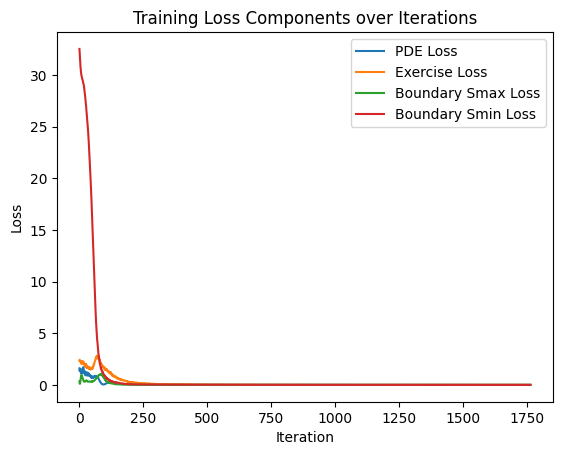

In [7]:
trainer_product.plot_losses_detailed()

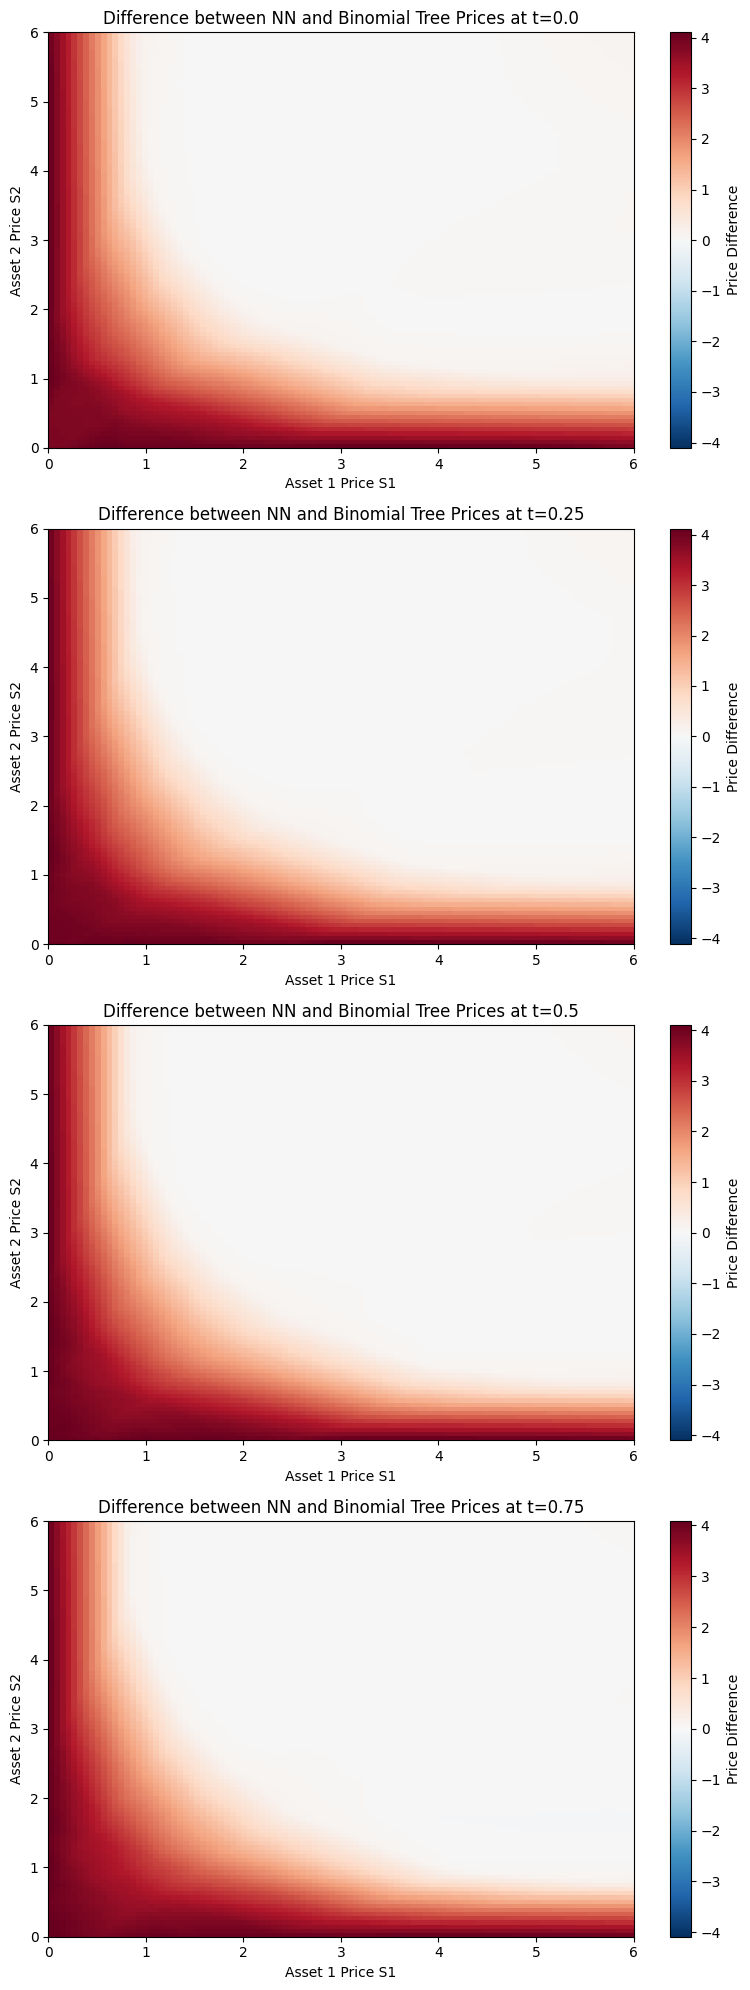

In [ ]:
# Heatmap of differences at different T
resolution = 100
S1 = np.linspace(0.0, 6.0, resolution)
S2 = np.linspace(0.0, 6.0, resolution)

ts = [0.0, 0.25, 0.5, 0.75]

plt.subplots(len(ts), 1, figsize=(8, 5 * len(ts)))
for i, t in enumerate(ts):
    S1_grid, S2_grid = np.meshgrid(S1, S2, indexing='ij')
    t_grid = np.full(S1_grid.shape, t)

    nn_prices = trainer_product.predict(t_grid.flatten(), S1_grid.flatten(), S2_grid.flatten()).detach().numpy().reshape(S1_grid.shape)

    plt.subplot(len(ts), 1, i + 1)
    vmax = np.abs(nn_prices).max()
    vmin = -vmax
    im = plt.imshow(nn_prices, extent=[S1[0], S1[-1], S2[0], S2[-1]],
                    aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
    plt.colorbar(im, label='Price')
    plt.xlabel('Asset 1 Price S1')
    plt.ylabel('Asset 2 Price S2')
    plt.title(f'NN Prices at t={t}')
plt.tight_layout()
plt.show()

## Compare with 1D case

In [10]:
r_1d = r * n_assets + np.sum(np.tril(sigma, k=-1))
sigma_1d = np.sqrt(np.sum(sigma))

market_params_1d = MarketParams(
    n_assets=1,
    S0=S0**n_assets,
    r=r_1d,
    sigma=sigma_1d,
    K=K,
    T=T,
    S_min=S_min**n_assets,
    S_max=S_max**n_assets
)

bt_1d = BinomialTree(market_params_1d, n_steps = 100)


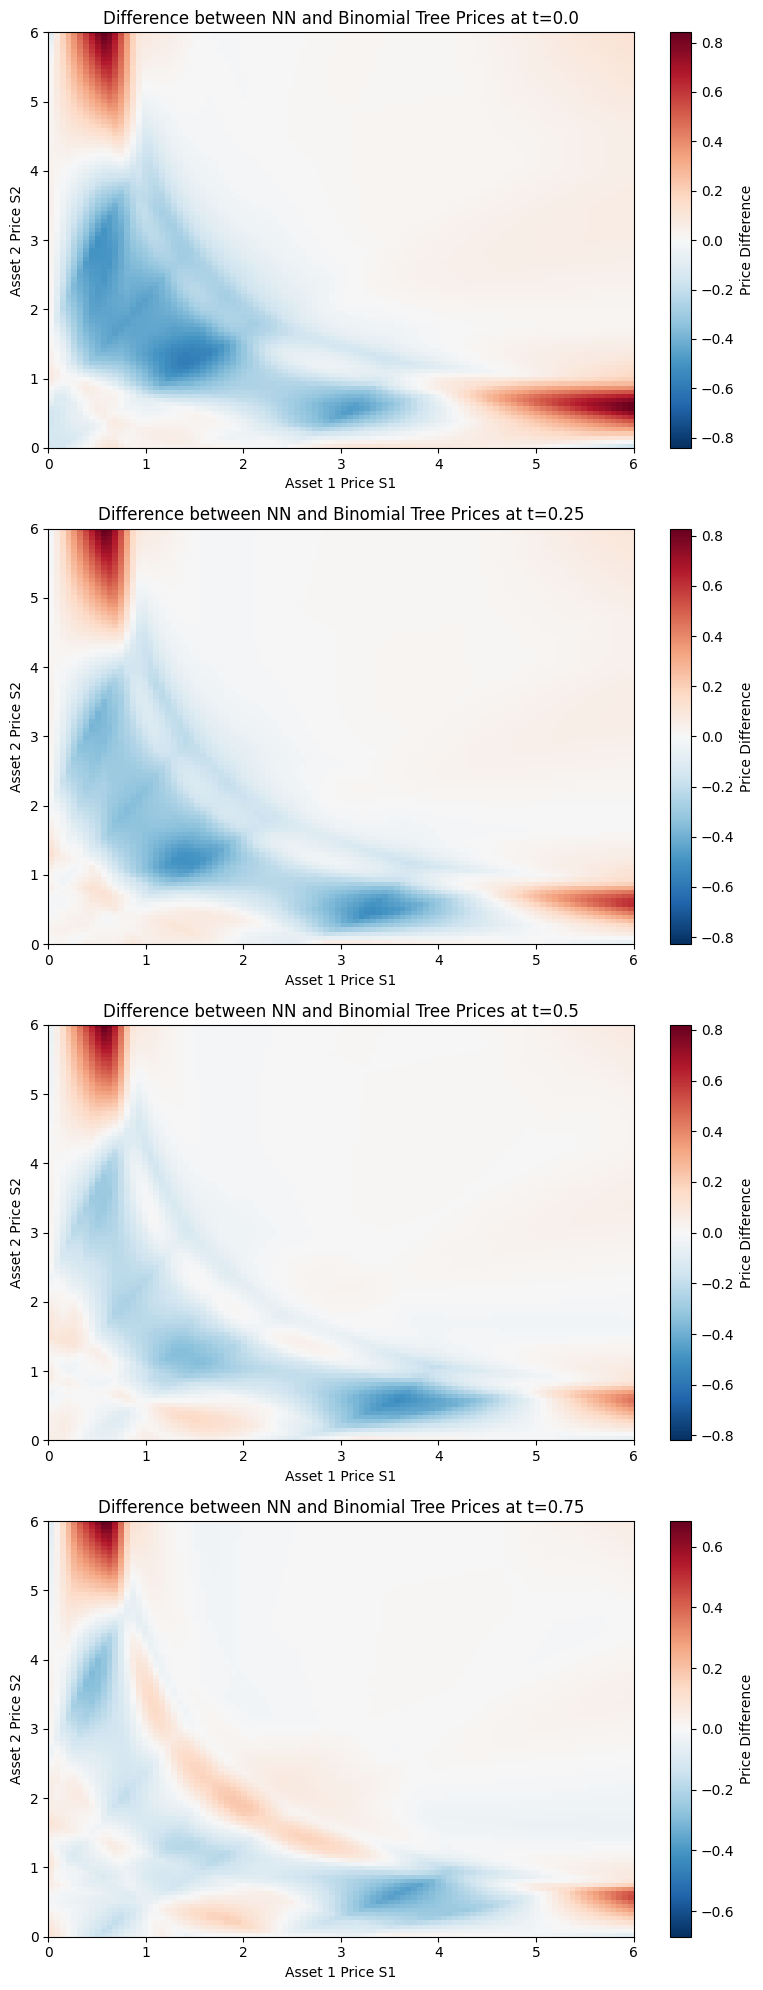

In [11]:
# Heatmap of differences at different T
resolution = 100
S1 = np.linspace(0.0, 6.0, resolution)
S2 = np.linspace(0.0, 6.0, resolution)

ts = [0.0, 0.25, 0.5, 0.75]

plt.subplots(len(ts), 1, figsize=(8, 5 * len(ts)))
for i, t in enumerate(ts):
    S1_grid, S2_grid = np.meshgrid(S1, S2, indexing='ij')
    t_grid = np.full(S1_grid.shape, t)

    nn_prices = trainer_product.predict(t_grid.flatten(), S1_grid.flatten(), S2_grid.flatten()).detach().numpy().reshape(S1_grid.shape)
    bt_prices = bt_1d.predict(t, (S1_grid * S2_grid).flatten()).reshape(S1_grid.shape)

    diff = nn_prices - bt_prices

    plt.subplot(len(ts), 1, i + 1)
    vmax = np.abs(diff).max()
    vmin = -vmax
    im = plt.imshow(diff, extent=[S1[0], S1[-1], S2[0], S2[-1]],
                    aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
    plt.colorbar(im, label='Price Difference')
    plt.xlabel('Asset 1 Price S1')
    plt.ylabel('Asset 2 Price S2')
    plt.title(f'Difference between NN and Binomial Tree Prices at t={t}')
plt.tight_layout()
plt.show()